Project code

In [1]:
import json

import pandas as pd
import numpy as np
import re
from wordcloud import WordCloud
from sklearn.metrics import classification_report
from simpletransformers.classification import ClassificationModel, ClassificationArgs
from collections import Counter

## Preprocessing for NER dataset

## Dataset statistics for NER dataset

## Model for NER

## Preprocessing for sentiment classification dataset

In [12]:
files_sentiment_path = ['sentiment_analysis_data/training_data_1.json', 
                        'sentiment_analysis_data/training_data_2.json']

def mergeJSONfiles(filename):
    training_data_sentiment = {}
    counter = 1
    for file in filename:
        with open(file, 'r', encoding='utf-8') as sentiment_data:
            data = json.load(sentiment_data)
            for key in data:
                training_data_sentiment[str(counter)] = data[key]
                counter += 1
    
    with open('sentiment_analysis_data/merged_training_data.json', 'w', encoding='utf-8') as output_file:
        json.dump(training_data_sentiment, output_file, indent=4)
    
mergeJSONfiles(files_sentiment_path)

In [14]:
sentiment_file_path = 'sentiment_analysis_data/merged_training_data.json'

with open(sentiment_file_path, 'r') as sentiment_data:
    training_data_sentiment = json.load(sentiment_data)
    
print(training_data_sentiment['4000000'])

{'sentiment_label': 'positive', 'text_of_tweet': "Makes My Blood Run Red-White-And-Blue: I agree that every American should read this book -- and everybody else for that matter. I don't agree that it's scholarly. Rather, it's a joy to read -- easy to understand even for a person with two master's degrees! Between McElroy's chapter on How American Culture was Formed and Ken Burns' Lewis & Clark, I don't know which makes my blood run red-white-and-bluer. And as a child of the anti-establishment `60s, it's done a lot toward helping me understand why we Americans do what we do. It's the best history book I've ever read, the best history course I've ever taken or taught. I'm buying it for my home library for my grandchildren to use as a resource. We're also using it as a resource for a book on urban planning."}


## Dataset statistics for sentiment classification

## Model for sentiment classification

## Preprocessing for topic classification dataset

In [9]:
topic_path = 'topic_classification_data/big_data.csv'

training_data_topic = pd.read_csv(topic_path)
training_data_topic = training_data_topic.drop(columns=['Unnamed: 0'])
print(training_data_topic.shape)
training_data_topic.head()

# Dataset link: https://www.kaggle.com/datasets/aronferencz/topic-analysis-dataset-sportbookmovie

(120307, 2)


,review,label
0,I'm only a third way in. Shipped lightening fa...,book
1,"""There have been so many times when I was scar...",book
2,The media could not be loaded. I personally ha...,book
3,I have been a fan of Britney's music since the...,book
4,"Whether or not you’re a fan, it’s a great read...",book


In [16]:
print(training_data_topic['review'])

0         I'm only a third way in. Shipped lightening fa...
1         "There have been so many times when I was scar...
2         The media could not be loaded. I personally ha...
3         I have been a fan of Britney's music since the...
4         Whether or not you’re a fan, it’s a great read...
                                ...                        
120302     VAL GARDENA, Italy (Reuters) - Max Rauffer be...
120303    Red Sox general manager Theo Epstein acknowled...
120304    The Miami Dolphins will put their courtship of...
120305    PITTSBURGH at NY GIANTS Time: 1:30 p.m. Line: ...
120306    INDIANAPOLIS -- All-Star Vince Carter was trad...
Name: review, Length: 120307, dtype: object


In [18]:
training_data_topic['review_processed'] = training_data_topic['review'].astype(str).map(lambda x: re.sub(r'[,\.!?]', '', x) if x != 'nan' else '')

# Convert the titles to lowercase
training_data_topic['review_processed'] = training_data_topic['review_processed'].str.lower()

# Print out the first rows of papers
training_data_topic['review_processed'].head()

0    i'm only a third way in shipped lightening fas...
1    "there have been so many times when i was scar...
2    the media could not be loaded i personally hav...
3    i have been a fan of britney's music since the...
4    whether or not you’re a fan it’s a great read ...
Name: review_processed, dtype: object

In [21]:
training_data_topic.head()

,review,label,review_processed
0,I'm only a third way in. Shipped lightening fa...,book,i'm only a third way in shipped lightening fas...
1,"""There have been so many times when I was scar...",book,"""there have been so many times when i was scar..."
2,The media could not be loaded. I personally ha...,book,the media could not be loaded i personally hav...
3,I have been a fan of Britney's music since the...,book,i have been a fan of britney's music since the...
4,"Whether or not you’re a fan, it’s a great read...",book,whether or not you’re a fan it’s a great read ...


## Dataset statistics for topic modelling

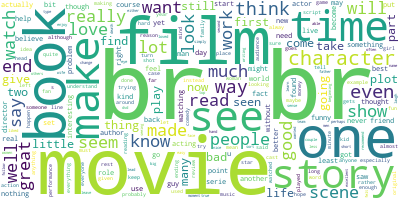

In [20]:
long_string = ','.join(list(training_data_topic['review_processed'].values))

wordcloud = WordCloud(background_color="white", max_words=1000, contour_width=3, contour_color='steelblue')

wordcloud.generate(long_string)

wordcloud.to_image()

## Model for topic classification

In [ ]:
# Model configuration
roberta_args = ClassificationArgs()

roberta_args.overwrite_output_dir=True
roberta_args.evaluate_during_training=True

roberta_args.num_train_epochs=10
roberta_args.train_batch_size=32
roberta_args.learning_rate=4e-6
roberta_args.max_seq_length=256

roberta_args.use_early_stopping=True
roberta_args.early_stopping_delta=0.01

roberta_args.early_stopping_metric='eval_loss'
roberta_args.early_stopping_metric_minimize=True
roberta_args.early_stopping_patience=2
roberta_args.evaluate_during_training_steps=32

# Kept the same as BERT to equally compare the models

steps_per_epoch = int(np.ceil(len(training_data_topic) / float(roberta_args.train_batch_size)))
print('Each epoch will have {:,} steps.'.format(steps_per_epoch))